In [2]:
# Install necessary libraries
%pip install numpy pandas scikit-learn matplotlib seaborn tensorflow keras joblib
%pip install statsmodels numpy scipy patsy plotly
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import plotly.express as px


[notice] A new release of pip available: 22.2.2 -> 24.3.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.2.2 -> 24.3.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Load dataset
data = pd.read_csv('household_power_consumption.txt', sep=';', 
                   parse_dates={'datetime': ['Date', 'Time']}, 
                   infer_datetime_format=True, 
                   na_values=['?'], 
                   low_memory=False)
print(data.head())

# Preprocess data
## Convert data types
data = data.astype({'Global_active_power': 'float64', 
                    'Global_reactive_power': 'float64', 
                    'Voltage': 'float64', 
                    'Global_intensity': 'float64', 
                    'Sub_metering_1': 'float64', 
                    'Sub_metering_2': 'float64', 
                    'Sub_metering_3': 'float64'})

# Handle missing values
data.dropna(inplace=True)

# Set datetime as index
data.set_index('datetime', inplace=True)


# Extract time-based features
data['hour'] = data.index.hour
data['day_of_week'] = data.index.dayofweek
data['is_weekend'] = data['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

/var/folders/_1/zb6p0cnx2bzdgcq662_dmxx80000gn/T/ipykernel_34810/458458476.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data = pd.read_csv('household_power_consumption.txt', sep=';',
/var/folders/_1/zb6p0cnx2bzdgcq662_dmxx80000gn/T/ipykernel_34810/458458476.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('household_power_consumption.txt', sep=';',
/var/folders/_1/zb6p0cnx2bzdgcq662_dmxx80000gn/T/ipykernel_34810/458458476.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data = pd.read_csv('househo

             datetime  Global_active_power  Global_reactive_power  Voltage  \
0 2006-12-16 17:24:00                4.216                  0.418   234.84   
1 2006-12-16 17:25:00                5.360                  0.436   233.63   
2 2006-12-16 17:26:00                5.374                  0.498   233.29   
3 2006-12-16 17:27:00                5.388                  0.502   233.74   
4 2006-12-16 17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define features and target
X = data[['hour', 'day_of_week', 'is_weekend']]
y = data['Global_active_power']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 0.8925082143204595
R2 Score: 0.2059136169343585


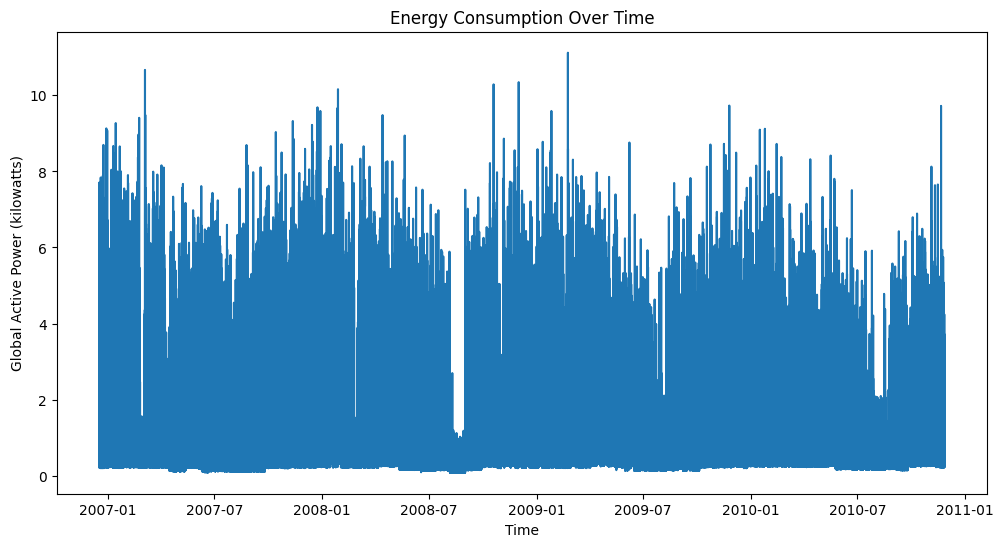

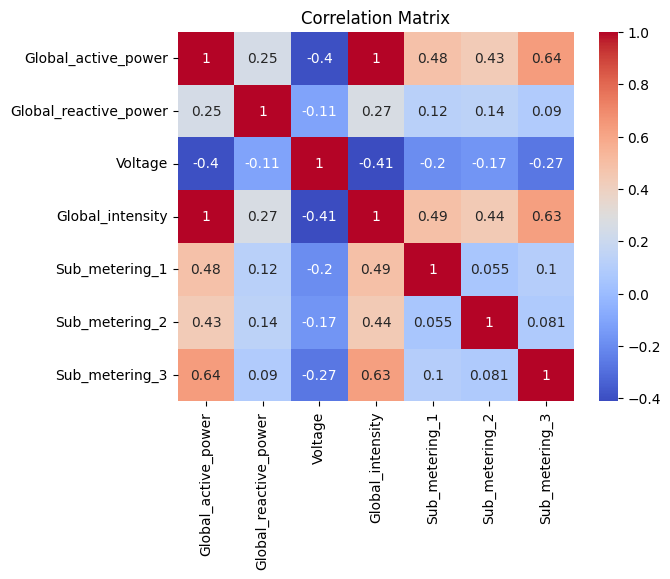

In [6]:
# Visualize energy consumption trends
plt.figure(figsize=(12, 6))
sns.lineplot(x=data.index, y=data['Global_active_power'])
plt.title('Energy Consumption Over Time')
plt.xlabel('Time')
plt.ylabel('Global Active Power (kilowatts)')
plt.show()

# Correlation matrix
# Select numeric columns for correlation
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 
                'Sub_metering_3']
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [7]:
# Identify peak hours
peak_hours = data.groupby('hour')['Global_active_power'].mean().sort_values(ascending=False).head()
print("Peak Hours:\n", peak_hours)

# Suggest load shifting
def suggest_shifting(hour):
    if hour in peak_hours.index:
        return "Shift to off-peak hours"
    return "No change needed"

data['optimization_suggestion'] = data['hour'].apply(suggest_shifting)
print(data[['hour', 'optimization_suggestion']])

Peak Hours:
 hour
20    1.899064
21    1.877697
19    1.733335
7     1.502246
8     1.461016
Name: Global_active_power, dtype: float64
                     hour  optimization_suggestion
datetime                                          
2006-12-16 17:24:00    17         No change needed
2006-12-16 17:25:00    17         No change needed
2006-12-16 17:26:00    17         No change needed
2006-12-16 17:27:00    17         No change needed
2006-12-16 17:28:00    17         No change needed
...                   ...                      ...
2010-11-26 20:58:00    20  Shift to off-peak hours
2010-11-26 20:59:00    20  Shift to off-peak hours
2010-11-26 21:00:00    21  Shift to off-peak hours
2010-11-26 21:01:00    21  Shift to off-peak hours
2010-11-26 21:02:00    21  Shift to off-peak hours

[2049280 rows x 2 columns]



[notice] A new release of pip available: 22.2.2 -> 24.3.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


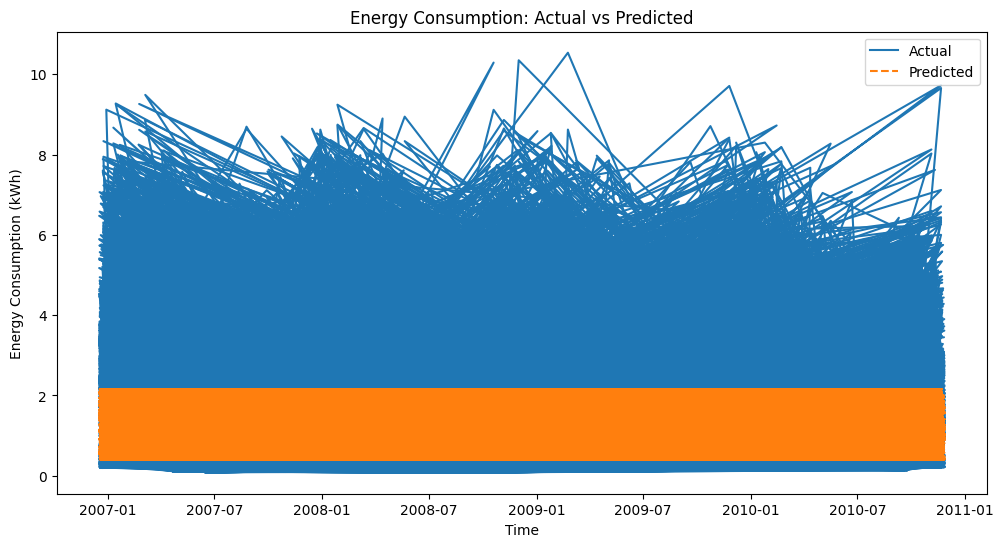

In [ ]:
%pip install nbformat
import matplotlib as mpl
import matplotlib.pyplot as plt
# Set the agg.path.chunksize parameter
mpl.rcParams['agg.path.chunksize'] = 10000
# Plot predictions vs actuals
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted', linestyle='--')
plt.legend()
plt.title('Energy Consumption: Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Energy Consumption (kWh)')
plt.show()

# Interactive dashboard using Plotly
fig = px.line(data, x=data.index, y='Global_active_power', title='Energy Consumption Over Time')
fig.show()